Faça o upload do arquivo data.pkl com os dados fornecidos para a atividade. Use a célula de comando abaixo após a finalização do upload para a preparação do conteúdo do arquivo no colab.

In [1]:
#=======================
# não altere essa célula
#=======================

import pickle
from torch.utils.data import DataLoader
import numpy as np

with open('data.pkl', 'rb') as handle:
    dataset = pickle.load(handle)

training_data = list(zip(dataset['x'].astype(np.float32),dataset['y']))
test_data = list(zip(dataset['x_test'].astype(np.float32),dataset['y_test']))

train_dataloader = DataLoader(training_data, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_data, batch_size=100, shuffle=False)

O dataset representa uma tarefa de classificação com 10 classes e é composto por um input sequencial com 40 float features e um output inteiro contendo o índice da classe de cada amostra (i.e. de 0 a 9).

In [2]:
for X, y in train_dataloader:
    print(f"Shape of X [N, L]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, L]: torch.Size([32, 40])
Shape of y: torch.Size([32]) torch.int64


o formato de cada amostra é 

40 -> Tamanho da entrada

32 -> Tamanho do batch

4000 -> Número de amostras


LENDO O LIVRO UNDERSTANDING DEEP LEARNING, FOI PERCEBIDO QUE OS DADOS TEM AS MESMAS INFORMAÇÕES DO MNIST-1D, E PROVAVELMENTE SÃO O MNIST-1D

In [3]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


Altere as classes abaixo implementando os seguintes modelos:

1. modelo de classificação linear
2. mlp com no máximo 20k parâmetros (contando pesos e biases)
3. rede convolucional estilo LeNet
4. rede convolucional estilo VGG
5. rede convolucional estilo ResNet

(extra)
6. rede recorrente
7. rede estilo ViT

In [87]:
# Define model
class LinearNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.pesos = nn.Linear(40, 10, bias=True)

    def forward(self, x):
        x = self.pesos(x)  # Aplicar os pesos e bias
        return x

# Define model
class MLPNet(nn.Module):
    def __init__(self):
        super().__init__()
        '''Nessa rede temos ao total 18.760 parâmetros, para obter esse número basta contar a quantidade de neurônios multiplicado pela quantidade de entradas + 1 (bias), isso para cada camada da rede. Asim, temos:
            200 * 41 = 8.200
            50 * 201 = 10.050
            10 * 51 = 510
            
            Somando tudo temos os 18.760 parâmetros descritos, incluindo pesos e bias.'''
        
        self.fc1 = nn.Linear(40, 200, bias = True)
        self.fc2 = nn.Linear(200, 50, bias = True)
        self.fc3 = nn.Linear(50, 10, bias = True)
        
        '''fc é uma abraviação para fully conected (totalmente conectada), que é o conceito de uma mlp, onde todas as entradas estão conectadas atráves de um peso a cada neurônio, e cada saída de uma camada pode ser entrada para uma proxima.'''

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # Não requer função softmax, pois a mesma já está implicita na escolha da loss como CrossEntropyLoss
        return x 

# Define model
class LeNet(nn.Module):
    '''Em um alto nível, o LeNet (LeNet-5) consiste em duas partes: um codificador convolucional consistindo de duas camadas convolucionais; e um bloco denso consistindo de três camadas totalmente conectadas. Além disso contamos com as camadas de pooling e funções de ativação, no paper original é utilizado sigmoid/tangente hiperbólica, nessa implementação usaremos a relu, como também, usaremos a conv1d, pois se tratam de dados não bidimensionais . Um ponto de extrema atenção, é que ReLUs e max-pooling ainda não haviam sido descobertos na idealização da LeNet, mas serão utilizadas, pois geram um bom aumento de desempenho, juntamente com a softmax presente na função de perca, diferente do decodificador gaussiano, inicialmente proposto. Além disso, a arquitetura segue o seguinte modelo:
        
        Primeira Camada Convolucional: a primeira camada convolucional possui 6 filtros 1x5 com stride 1 e padding 2, essa escolha foi feita para manter o resultado da convolução com o mesmo tamanho de sua entrada (40). Assim, se assemelhando mais a resnet tradicional que após a primeira convolução, gera um feature map de 6 por 28x28 (mesmo tamanho da entrada).
        
        Primeira Camada de pooling: a primeira camada de pooling é um max_pooling 1x2 com stride 2, assim reduzindo o tamanho de x pela metade (20), assim como na publicação da resnet.
        
        Segunda Camada Convolucional: a segunda camada convolucional implementa 16 filtros 1x5, com stride 1 e padding 0, assim reduzindo o tamanho de x para 16x16, onde temos 16 mapas de taamnho 16 cada. Redução proporcional a resnet original
        
        Segunda Camada de pooling: a segunda camada de pooling é um max_pooling 1x2 com stride 2, reduzindo x para 16x8, 16 mapas com 8 de tamanho cada, tendo papel semelhante a da implementação original que reduz o resultado da segunda camada convolucional pela metade.
        
        A partir dai as features sofrem um flatten (achatamento) e servirão de entrada para uma totalmente conectada (mlp), essa totalmente conectada tem :
        
            Primeira camada mlp: 50 neurônios com 16*8 pesos cada, quantidade de "features" que temos após aplicar a segunda camada de pooling. 
            Segunda camada mlp: 30 neurônios com 50 pesos cada, quantidade de neurônios da camada anterior. 
            Terceira camada mlp: 10 neurônios (quantidade de classes) com 30 pesos cada, quantidade de neurônios da camada anterior. 
            
            O número de neurônios da totalmente conectada foi reduzido, visto que na original haviam 120, 84 e 10 neurônios por cada, isso foi feito a fim de gerar menos parâmetros que a mlp anteriormente implementada.
        '''


    '''Calculo dos parâmetros:
           Para os kernels, temos in_channels * kernel_size * out_channels + out_channles(bias) por camada, assim, temos:
           
                conv1: 1x6x5 + 6 = 36 parâmetros
                conv2: 6x5x16 + 16 = 496 parâmetros
                
                fc1: 50 x (16*8 + 1) = 6450 parâmetros
                fc2: 30 x 51 = 1530 parâmetros
                fc3: 10 x 31 = 310 parâmetros
                
            Desse modo, nossa lenet possui 8.822 parâmetros, contabilizando pesos e bias, sendo mais de 2 vezes menor que a mlp implementada.
                '''
    
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2, padding_mode='zeros')  
        self.conv2 = nn.Conv1d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0)

        self.fc1 = nn.Linear(16 * 8, 50, bias = True)
        self.fc2 = nn.Linear(50, 30, bias = True)
        self.fc3 = nn.Linear(30, 10, bias = True)

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)  # Reshape para [batch_size, 1, 40]

        x = F.relu(self.conv1(x))
        x = F.max_pool1d(x, kernel_size=2, stride=2)

        x = F.relu(self.conv2(x))
        x = F.max_pool1d(x, kernel_size=2, stride=2)

        x = x.view(x.size(0), -1)  # Achata o tensor antes das camadas totalmente conectadas

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # Não requer função softmax, pois a mesma já está implicita na escolha da loss como CrossEntropyLoss

        return x

# Define model
class VGGNet(nn.Module):
    '''
Em um alto nível, a VGGNet segue a ideia de usar muitas camadas convolucionais com filtros pequenos, aumentando a profundidade da rede. A VGGNet foi originalmente proposta com filtros 3x3, mas para esta implementação usaremos `conv1d` com filtros 1x3, já que estamos lidando com dados unidimensionais. Além disso, a implementação utiliza ReLUs e camadas de pooling, assim como na versão original, para melhorar o desempenho.

A arquitetura segue o seguinte modelo:

    Primeira Camada Convolucional: A primeira camada convolucional possui 64 filtros 1x3 com padding 1. Isso garante que o tamanho da saída seja o mesmo que o da entrada. Essa camada é seguida por outra camada convolucional com as mesmas especificações.
    
    Primeira Camada de Pooling: Um `max_pooling` 1x2 com stride 2, reduzindo o tamanho da sequência pela metade.
    
    Segunda Camada Convolucional: A segunda camada convolucional implementa 128 filtros 1x3 com padding 1, mantendo o tamanho da sequência. Esta camada é seguida por outra camada convolucional com as mesmas especificações.
    
    Segunda Camada de Pooling: Um `max_pooling` 1x2 com stride 2, reduzindo o tamanho da sequência pela metade.
    
    Terceira Camada Convolucional: A terceira camada convolucional possui 256 filtros 1x3 com padding 1. Essa camada é seguida por duas outras camadas convolucionais com as mesmas especificações.
    
    Terceira Camada de Pooling: Um `max_pooling` 1x2 com stride 2, novamente reduzindo o tamanho da sequência pela metade.
    
    Quarta Camada Convolucional: A quarta camada convolucional possui 512 filtros 1x3 com padding 1. Essa camada é seguida por duas outras camadas convolucionais com as mesmas especificações.
    
    Quarta Camada de Pooling: Um `max_pooling` 1x2 com stride 2, reduzindo o tamanho da sequência pela metade.
    
    Quinta Camada Convolucional: A quinta camada convolucional possui 512 filtros 1x3 com padding 1. Essa camada é seguida por duas outras camadas convolucionais com as mesmas especificações.
    
    Quinta Camada de Pooling: Um `max_pooling` 1x2 com stride 2, novamente reduzindo o tamanho da sequência pela metade.

Após essas camadas convolucionais, os dados são achatados e passados para camadas totalmente conectadas:

    Primeira Camada MLP: 4096 neurônios com 512 * 1 pesos cada, considerando a saída da última camada de pooling.
    Segunda Camada MLP: 4096 neurônios com 4096 pesos cada, para aumentar a capacidade da rede de aprender padrões complexos.
    Terceira Camada MLP: 10 neurônios (quantidade de classes) com 4096 pesos cada.

Assim, a arquitetura VGGNet-1D implementada possui muitas camadas convolucionais, cada uma com um número relativamente pequeno de filtros, mas com uma grande profundidade, permitindo à rede aprender representações mais complexas dos dados.

Cálculo dos parâmetros:
Para os kernels, temos in_channels * kernel_size * out_channels + out_channels(bias) por camada, assim temos:

    conv1: 1x3x64 + 64 = 256 parâmetros
    conv2: 64x3x64 + 64 = 12,352 parâmetros
    conv3: 64x3x128 + 128 = 24,832 parâmetros
    conv4: 128x3x128 + 128 = 49,280 parâmetros
    conv5: 128x3x256 + 256 = 98,560 parâmetros
    conv6: 256x3x256 + 256 = 196,864 parâmetros
    conv7: 256x3x256 + 256 = 196,864 parâmetros
    conv8: 256x3x512 + 512 = 393,216 parâmetros
    conv9: 512x3x512 + 512 = 786,432 parâmetros
    conv10: 512x3x512 + 512 = 786,432 parâmetros
    conv11: 512x3x512 + 512 = 786,432 parâmetros
    conv12: 512x3x512 + 512 = 786,432 parâmetros
    conv13: 512x3x512 + 512 = 786,432 parâmetros

Total de parâmetros nas camadas convolucionais: 4,679,416

    fc1: 4096 x (512*1 + 1) = 2,100,992 parâmetros
    fc2: 4096 x (4096 + 1) = 16,781,312 parâmetros
    fc3: 10 x (4096 + 1) = 40,960 parâmetros

Total de parâmetros nas camadas totalmente conectadas: 18,923,264

Desse modo, a VGGNet-1D possui 23,602,680 parâmetros, contabilizando pesos e bias, tornando-a uma rede extremamente poderosa e capaz de aprender padrões complexos nos dados unidimensionais.
'''


    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            # Primeira camada convolucional
            nn.Conv1d(1, 64, kernel_size=3, padding=1),  # 64 filtros, 3 kernels
            nn.ReLU(inplace=True),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),  # 64 filtros, 3 kernels
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),  # Max pooling com 2 kernel

            # Segunda camada convolucional
            nn.Conv1d(64, 128, kernel_size=3, padding=1),  # 128 filtros, 3 kernels
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),  # 128 filtros, 3 kernels
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),  # Max pooling com 2 kernel

            # Terceira camada convolucional
            nn.Conv1d(128, 256, kernel_size=3, padding=1),  # 256 filtros, 3 kernels
            nn.ReLU(inplace=True),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),  # 256 filtros, 3 kernels
            nn.ReLU(inplace=True),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),  # 256 filtros, 3 kernels
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),  # Max pooling com 2 kernel

            # Quarta camada convolucional
            nn.Conv1d(256, 512, kernel_size=3, padding=1),  # 512 filtros, 3 kernels
            nn.ReLU(inplace=True),
            nn.Conv1d(512, 512, kernel_size=3, padding=1),  # 512 filtros, 3 kernels
            nn.ReLU(inplace=True),
            nn.Conv1d(512, 512, kernel_size=3, padding=1),  # 512 filtros, 3 kernels
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),  # Max pooling com 2 kernel

            # Quinta camada convolucional
            nn.Conv1d(512, 512, kernel_size=3, padding=1),  # 512 filtros, 3 kernels
            nn.ReLU(inplace=True),
            nn.Conv1d(512, 512, kernel_size=3, padding=1),  # 512 filtros, 3 kernels
            nn.ReLU(inplace=True),
            nn.Conv1d(512, 512, kernel_size=3, padding=1),  # 512 filtros, 3 kernels
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)  # Max pooling com 2 kernel
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(512 * 1, 4096),  # Ajuste de acordo com a saída da última camada de pooling
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 10)  # Camada de saída com 10 neurônios (para 10 classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)  # Reshape para [batch_size, 1, 40]
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Achata o tensor antes das camadas totalmente conectadas
        x = self.fc_layers(x)
        return x

# Define model
class ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        #TODO

    def forward(self, x):
        #TODO
        pass

# Define model
class RecurrentNet(nn.Module):
    def __init__(self):
        super().__init__()
        #TODO

    def forward(self, x):
        #TODO
        pass

# Define model
class ViTNet(nn.Module):
    def __init__(self):
        super().__init__()
        #TODO

    def forward(self, x):
        #TODO
        pass

Escolha o modelo implementado, a função de custo e o otimizador e treine o modelo até atingir a melhor acurácia possível no conjunto de teste.

In [88]:
# altere o modelo nessa célula
model = LeNet().to(device)
print(model)

LeNet(
  (conv1): Conv1d(1, 6, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv2): Conv1d(6, 16, kernel_size=(5,), stride=(1,))
  (fc1): Linear(in_features=128, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=30, bias=True)
  (fc3): Linear(in_features=30, out_features=10, bias=True)
)


In [89]:
# altere a função de custo e o otimizador nessa célula
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

In [90]:
#=======================
# não altere essa célula
#=======================

def train(dataloader, model, loss_fn, optimizer):
    train_loss = []
    train_acc = []

    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += [loss.item()]

        correct = (pred.argmax(1) == y).type(torch.float).mean().item()
        train_acc += [100*correct]

    return train_loss, train_acc

In [91]:
#=======================
# não altere essa célula
#=======================

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    test_acc = 100*correct/size

    return test_loss, test_acc

Escolha o número de épocas para o treinamento.

In [92]:
epochs = 50

In [93]:
#=======================
# não altere essa célula
#=======================

from tqdm import trange
import numpy as np

train_loss_hist = []
train_acc_hist = []

test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
test_loss_hist = [test_loss_0]
test_acc_hist = [test_acc_0]

print(f"Initial Test Loss: {test_loss_0:.4f}, Initial Test Accuracy: {test_acc_0:.4f}")

for t in range(epochs):
    train_loss, train_acc = train(train_dataloader, model, loss_fn, optimizer)
    train_loss_hist.append(np.mean(train_loss))
    train_acc_hist.append(np.mean(train_acc))

    test_loss, test_acc = test(test_dataloader, model, loss_fn)
    test_loss_hist.append(test_loss)
    test_acc_hist.append(test_acc)
    if t % 10 == 0:
        print(f"Epoch {t+1}/{epochs}:")
        print(f"Train Loss: {train_loss_hist[-1]:.4f}, Train Accuracy: {train_acc_hist[-1]:.4f}")
        print(f"Test Loss: {test_loss_hist[-1]:.4f}, Test Accuracy: {test_acc_hist[-1]:.4f}")
        print('')

train_loss_hist = np.array(train_loss_hist)
test_loss_hist = np.array(test_loss_hist)
train_acc_hist = np.array(train_acc_hist)
test_acc_hist = np.array(test_acc_hist)

print("\nFinal Results")
print(f"Final Train Loss: {train_loss_hist[-1]:.4f}, Final Train Accuracy: {train_acc_hist[-1]:.4f}")
print(f"Final Test Loss: {test_loss_hist[-1]:.4f}, Final Test Accuracy: {test_acc_hist[-1]:.4f}")


Initial Test Loss: 2.3133, Initial Test Accuracy: 9.5000
Epoch 1/50:
Train Loss: 2.2971, Train Accuracy: 12.7500
Test Loss: 2.2403, Test Accuracy: 18.3000

Epoch 11/50:
Train Loss: 0.6250, Train Accuracy: 75.9750
Test Loss: 0.7590, Test Accuracy: 70.5000

Epoch 21/50:
Train Loss: 0.2088, Train Accuracy: 93.0000
Test Loss: 0.2822, Test Accuracy: 91.2000

Epoch 31/50:
Train Loss: 0.0876, Train Accuracy: 97.3250
Test Loss: 0.2804, Test Accuracy: 90.9000

Epoch 41/50:
Train Loss: 0.1381, Train Accuracy: 96.6750
Test Loss: 0.3052, Test Accuracy: 92.9000


Final Results
Final Train Loss: 0.0073, Final Train Accuracy: 99.8500
Final Test Loss: 0.3632, Final Test Accuracy: 93.4000


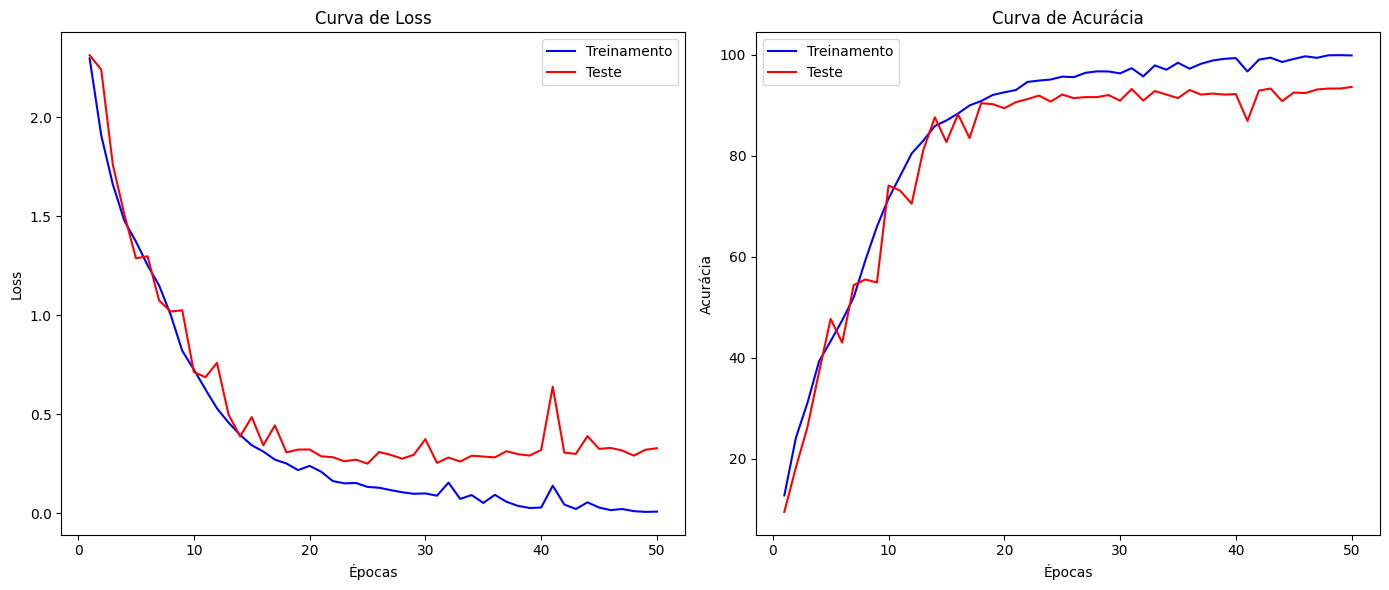

In [94]:
min_length = min(len(train_loss_hist), len(test_loss_hist), len(train_acc_hist), len(test_acc_hist))

train_loss_hist = train_loss_hist[:min_length]
test_loss_hist = test_loss_hist[:min_length]
train_acc_hist = train_acc_hist[:min_length]
test_acc_hist = test_acc_hist[:min_length]

epochs_range = np.arange(1, min_length + 1)

# Plotar as curvas de perda (loss) e acurácia (accuracy) ao longo das épocas
plt.figure(figsize=(14, 6))

# Plotar perda (loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_hist, label='Treinamento', color='blue')
plt.plot(epochs_range, test_loss_hist, label='Teste', color='red')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Curva de Loss')
plt.legend()

# Plotar acurácia (accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_hist, label='Treinamento', color='blue')
plt.plot(epochs_range, test_acc_hist, label='Teste', color='red')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.title('Curva de Acurácia')
plt.legend()

plt.tight_layout()
plt.show()

In [243]:
''''#=======================
# não altere essa célula
#=======================

from tqdm import trange

train_loss_hist = []
train_acc_hist = []

test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
test_loss_hist = [test_loss_0]
test_acc_hist = [test_acc_0]

for t in trange(epochs):
    train_loss, train_acc = train(train_dataloader, model, loss_fn, optimizer)
    train_loss_hist += train_loss
    train_acc_hist += train_acc

    test_loss, test_acc = test(test_dataloader, model, loss_fn)
    test_loss_hist += [test_loss]
    test_acc_hist += [test_acc]

train_loss_hist = np.array(train_loss_hist)
test_loss_hist = np.array(test_loss_hist)
train_acc_hist = np.array(train_acc_hist)
test_acc_hist = np.array(test_acc_hist)'''

100%|██████████| 50/50 [00:20<00:00,  2.38it/s]


In [236]:
import matplotlib.pyplot as plt

Execute essa célula para visualizar as curvas de loss.

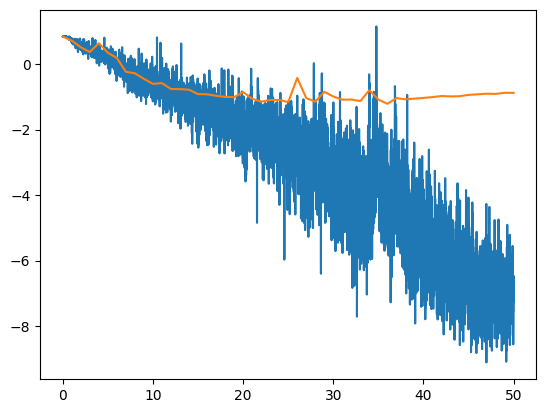

In [244]:
x_axis = np.linspace(0, epochs, len(train_loss_hist))
plt.plot(x_axis, np.log(train_loss_hist))
plt.plot(np.log(test_loss_hist))

Execute essa célula para visualizar as curvas de acurácia.

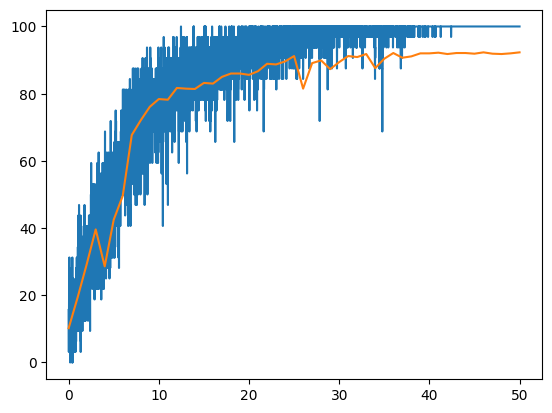

In [245]:
x_axis = np.linspace(0, epochs, len(train_acc_hist))
plt.plot(x_axis, train_acc_hist)
plt.plot(test_acc_hist)

Utilize os códigos acima para comparar os melhores modelos obtidos para cada arquitetura e, assim, faça um resumo das conclusões encontradas a partir dessas comparações.

## Linear (Pérceptron sem ativação) vs MLP

### LINEAR

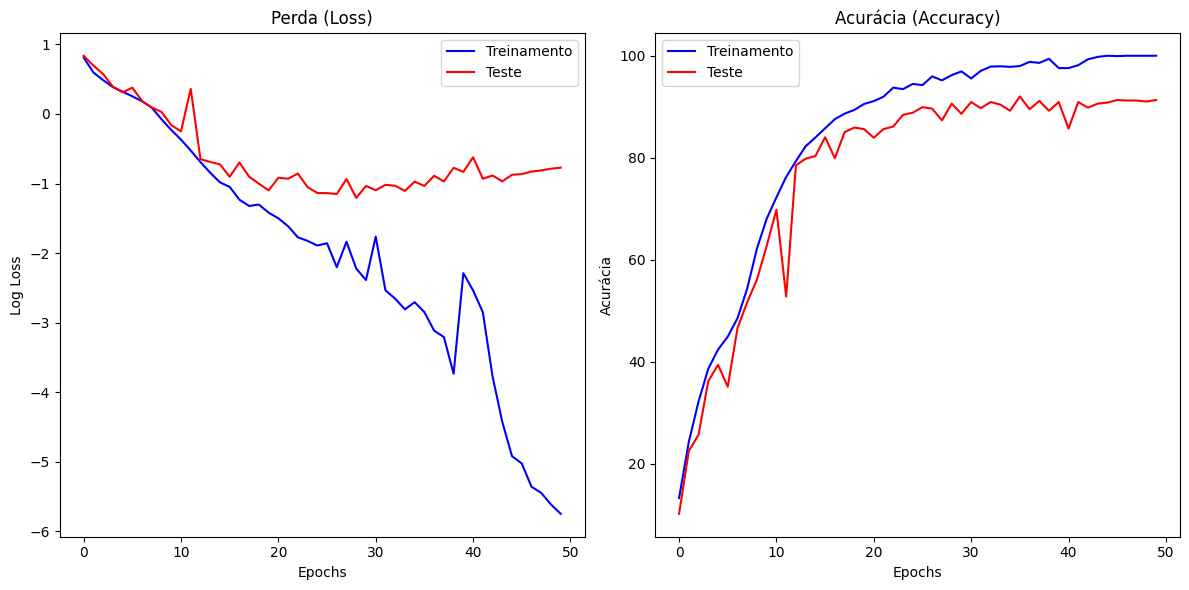

In [72]:
min_length = min(len(train_loss_hist), len(test_loss_hist))

train_loss_hist = train_loss_hist[:min_length]
test_loss_hist = test_loss_hist[:min_length]
train_acc_hist = train_acc_hist[:min_length]
test_acc_hist = test_acc_hist[:min_length]

# Plotar perda (loss)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
x_axis_loss = np.arange(min_length)  # Ajusta o comprimento da lista de perdas
plt.plot(x_axis_loss, np.log(train_loss_hist + 1e-10), label='Treinamento', color='blue')  # Adiciona uma pequena constante para evitar log(0)
plt.plot(x_axis_loss, np.log(test_loss_hist + 1e-10), label='Teste', color='red')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('Perda (Loss)')
plt.legend()

# Plotar acurácia (accuracy)
plt.subplot(1, 2, 2)
x_axis_acc = np.arange(min_length)  # Ajusta o comprimento da lista de acurácias
plt.plot(x_axis_acc, train_acc_hist, label='Treinamento', color='blue')
plt.plot(x_axis_acc, test_acc_hist, label='Teste', color='red')
plt.xlabel('Epochs')
plt.ylabel('Acurácia')
plt.title('Acurácia (Accuracy)')
plt.legend()

plt.tight_layout()
plt.show()

## LENET


É esperado que a LeNet, mesmo com menos parâmetros, tenha um desempenho melhor que uma MLP (Multi-Layer Perceptron). Isso ocorre porque, através da operação de convolução, é possível capturar relações espaciais e temporais entre as posições de entrada de maneira mais eficiente. Nas MLPs, essas relações precisam ser "aprendidas" exclusivamente por meio das conexões entre os neurônios, o que pode ser menos eficaz e exigir mais dados para um bom desempenho.

Além disso, fatores como a invariância são ocntribuintes nesse caso. Por exemplo, se o objetivo for, dado um conjunto de preços de uma determinada ação nos ultimos 40 dias, prever se no dia 41 ela vai subir ou não, uma informação de extrema importância, pode ser se houve ou não queda brusca na ação nos dias analisados. Essa informação é retirada a partir da relação dos dados de entrada, e não propriamente dos valores em si, além disso, a queda brusca pode acontecer em n posições possíveis, o que torna o problema complexo para mlp, demandando uma altissima quantidade de dados para representar a situação, além de precisar "aprender" essa relação. A operação de convolução ajuda bastante nesse problema, resolvendo a relação um para um imposta pela mlp. Esse ponto é favorecido se pensarmos que cada kernel é um neurônio que passeia pelas entradas, assim evitando essa localidade. Com isso, podemos dizer que a rede deve ser 

é possível observar que a mlp atinge 0 de erro no conjunto de treino, se pensarmos na mlp como um aproximador universal de funções, temos que a função formada pelo conjunto de treino é atinigível, mas essa não necessariamente é a função que resolve o problema, isso por que, sabemos que há dependência entre features, o que torna a função extremamente complexa para mlp. Se inserirmos conhecimento (convolução) seremos capazes de atingir um mesmo valor de loss no treino que a mlp, mas com um erro menor no teste. Isso por que, "facilitamos" a função a ser aprendida, quando passamos informações dos pixels ao redor 